# Experiment 1: Image Denoising using Wavelet Transform

## Problem
To remove noise from an image using wavelet transform.

## Theory
Wavelet transform decomposes an image into different frequency components.
Noise can be reduced by thresholding wavelet coefficients.

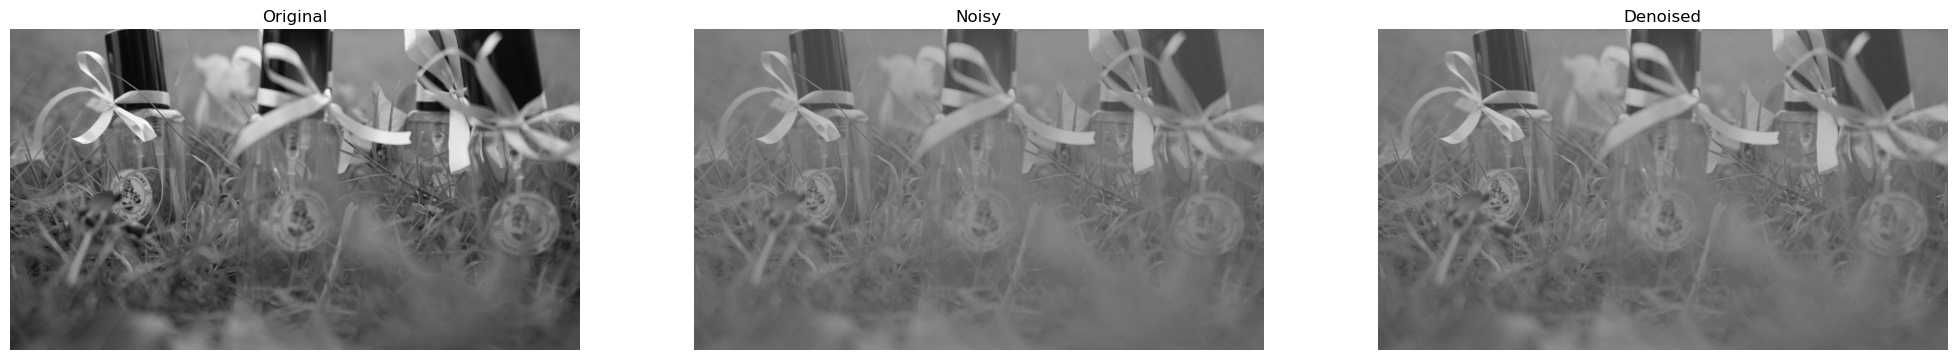

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt

img = cv2.imread('image.jpg', 0)

# Add noise
noise = np.random.normal(0, 25, img.shape)
noisy = img + noise

# Wavelet transform
coeffs = pywt.dwt2(noisy, 'haar')
cA, (cH, cV, cD) = coeffs

# Thresholding
cH = pywt.threshold(cH, 20, mode='soft')
cV = pywt.threshold(cV, 20, mode='soft')
cD = pywt.threshold(cD, 20, mode='soft')

# Reconstruction
denoised = pywt.idwt2((cA, (cH, cV, cD)), 'haar')

plt.figure(figsize=(25,15))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised")
plt.axis('off')

plt.show()

# Experiment 2: Wavelet Compression

## Problem
To verify compression property of wavelets.

## Theory
Most important information is stored in approximation coefficients.
Discarding small coefficients reduces storage.

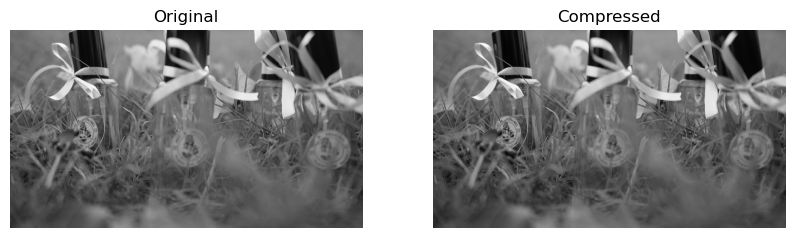

In [9]:
import pywt
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

coeffs = pywt.dwt2(img, 'haar')
cA, (cH, cV, cD) = coeffs

# Zero out detail coefficients (compression)
cH[:] = 0
cV[:] = 0
cD[:] = 0

compressed = pywt.idwt2((cA, (cH, cV, cD)), 'haar')

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(compressed, cmap='gray')
plt.title("Compressed")
plt.axis('off')

plt.show()

# Experiment 3: Image Deblurring

## Problem
To restore blurred image using inverse and Wiener filtering.

## Theory
Inverse filter reverses blur but is sensitive to noise.
Wiener filter balances noise removal and restoration.

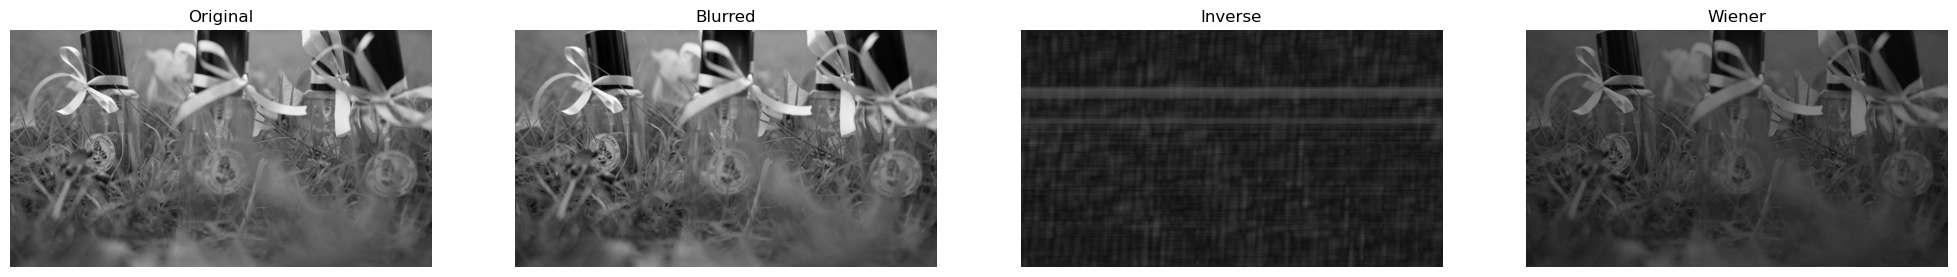

In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

# Create blur kernel
kernel = np.ones((5,5)) / 25

# Blur image
blurred = cv2.filter2D(img, -1, kernel)

# FFT
img_fft = np.fft.fft2(blurred)
kernel_fft = np.fft.fft2(kernel, s=img.shape)

# Inverse filter
inverse = np.fft.ifft2(img_fft / (kernel_fft + 1e-5))
inverse = np.abs(inverse)

# Wiener filter
K = 0.01
wiener = np.fft.ifft2((np.conj(kernel_fft) / (np.abs(kernel_fft)**2 + K)) * img_fft)
wiener = np.abs(wiener)

plt.figure(figsize=(25,15))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(blurred, cmap='gray')
plt.title("Blurred")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(inverse, cmap='gray')
plt.title("Inverse")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(wiener, cmap='gray')
plt.title("Wiener")
plt.axis('off')

plt.show()